# Lab: Visualización científica

**Meta:** convertir tablas en **gráficas** con `df.plot` (sobre matplotlib): una **línea** para una curva de crecimiento, una **barra** para comparar categorías (el `groupby` de la L22), una **dispersión** para ver la relación entre dos variables, y un **histograma** para ver la distribución de una medición. Y, en cada una, la regla de oro: **título, rótulos de eje con unidades y leyenda**. Acompaña a la nota de concepto [Visualización científica](l23_concept_visualization.qmd).

> **Cómo usar este lab:** ejecuta cada celda con `Shift + Enter`, empezando por las dos celdas de preparación. Cada gráfica se abre al ejecutar su celda (no imprime texto, dibuja una figura). Donde diga **Tu turno**, hay un bloque comentado con una parte marcada con `____` que debes **completar** al quitar los `#`. Compara con la respuesta esperada del bloque desplegable.

## Preparación

Para graficar necesitamos **matplotlib** (la librería de gráficas de Python; Pandas se apoya en ella) y **Pandas**. Corre estas **dos** celdas primero. La primera las instala (en Colab; si ya están, no hace nada). La segunda las importa: `plt` para matplotlib y `pd` para Pandas.

In [1]:
%pip install -q matplotlib pandas

Note: you may need to restart the kernel to use updated packages.


In [2]:
import matplotlib.pyplot as plt
import pandas as pd

print("matplotlib y pandas listos para trabajar")

matplotlib y pandas listos para trabajar


~~~text
matplotlib y pandas listos para trabajar
~~~

## Paso 1: gráfica de línea (una curva de crecimiento)

Una **línea** sirve para algo que cambia a lo largo de una variable continua, como el tiempo. Escribimos `crecimiento.csv` (la población de dos cultivos cada 2 horas) y lo leemos:

In [3]:
crecimiento = """hora,cultivo_A,cultivo_B
0,50,50
2,80,70
4,130,95
6,210,130
8,340,180
10,550,240
"""

with open('crecimiento.csv', 'w') as f:
    f.write(crecimiento)

df = pd.read_csv('crecimiento.csv')
print(df)

   hora  cultivo_A  cultivo_B
0     0         50         50
1     2         80         70
2     4        130         95
3     6        210        130
4     8        340        180
5    10        550        240


~~~text
   hora  cultivo_A  cultivo_B
0     0         50         50
1     2         80         70
2     4        130         95
3     6        210        130
4     8        340        180
5    10        550        240
~~~

Graficamos las dos columnas de población contra `hora`. Al pasar **varias** columnas en `y`, matplotlib dibuja una línea por cada una y agrega una **leyenda**. Fíjate en los rótulos con **unidades**:

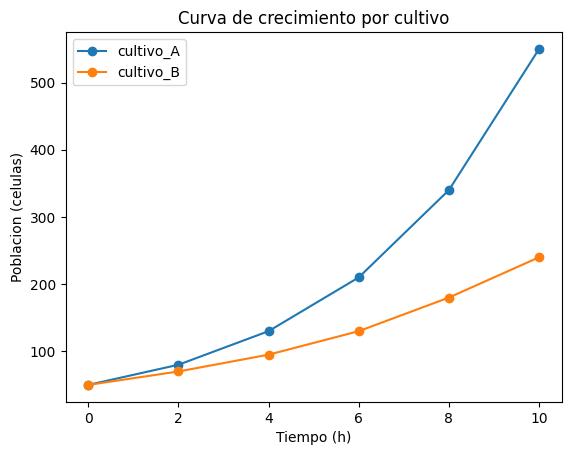

In [4]:
df.plot(x='hora', y=['cultivo_A', 'cultivo_B'],
        title='Curva de crecimiento por cultivo',
        xlabel='Tiempo (h)', ylabel='Poblacion (celulas)', marker='o')
plt.show()

*(Al ejecutar se abre la figura: dos líneas ascendentes -- `cultivo_A` despega más rápido que `cultivo_B` --, con leyenda, título y ejes rotulados con sus unidades.)*

## Paso 2: gráfica de barra (comparar categorías)

Una **barra** compara un valor entre categorías. Es la forma natural de **graficar un `groupby` de la L22**. Escribimos la misma `biodiversidad.csv` de la L22 y sumamos el conteo por especie:

In [5]:
biodiversidad = """sitio,especie,conteo
laguna_A,tilapia,15
laguna_B,molly,5
laguna_A,guppy,10
laguna_B,tilapia,25
laguna_A,tilapia,20
laguna_B,guppy,15
laguna_B,molly,10
"""

with open('biodiversidad.csv', 'w') as f:
    f.write(biodiversidad)

df = pd.read_csv('biodiversidad.csv')
totales = df.groupby('especie')['conteo'].sum()
print(totales)

especie
guppy      25
molly      15
tilapia    60
Name: conteo, dtype: int64


~~~text
especie
guppy      25
molly      15
tilapia    60
Name: conteo, dtype: int64
~~~

Ese resumen por grupo (lo que calculaste en la L22) se grafica con `.plot.bar()`:

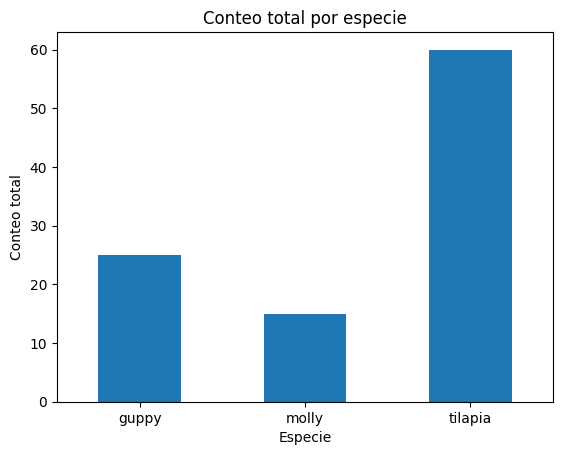

In [6]:
totales.plot.bar(title='Conteo total por especie',
                 xlabel='Especie', ylabel='Conteo total', rot=0)
plt.show()

*(Al ejecutar se abre la figura: tres barras, la de `tilapia` (60) mucho más alta que `guppy` (25) y `molly` (15). De un vistazo se ve cuál domina.)*

## Paso 3: gráfica de dispersión (relación entre dos variables)

Una **dispersión** (scatter) muestra si dos variables se mueven juntas. En química, la **absorbancia** de una muestra crece con su **concentración** (ley de Beer-Lambert). Escribimos `absorbancia.csv` y lo graficamos:

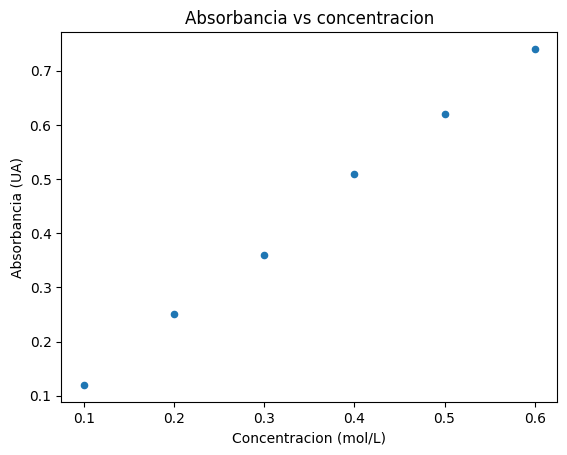

In [7]:
absorbancia = """concentracion,absorbancia
0.10,0.12
0.20,0.25
0.30,0.36
0.40,0.51
0.50,0.62
0.60,0.74
"""

with open('absorbancia.csv', 'w') as f:
    f.write(absorbancia)

df = pd.read_csv('absorbancia.csv')
df.plot.scatter(x='concentracion', y='absorbancia',
                title='Absorbancia vs concentracion',
                xlabel='Concentracion (mol/L)', ylabel='Absorbancia (UA)')
plt.show()

*(Al ejecutar se abre la figura: los puntos suben casi en línea recta -- a más concentración, más absorbancia. Esa relación lineal es la base de la ley de Beer-Lambert.)*

## Paso 4: histograma (la distribución de una medición)

Un **histograma** agrupa los valores de una columna en intervalos (`bins`) y cuenta cuántos caen en cada uno: muestra la **forma** de los datos. Escribimos 20 lecturas de pH y vemos su distribución:

In [8]:
lecturas = """ph
6.8
7.0
7.1
6.9
7.2
7.0
6.7
7.3
7.1
6.9
7.0
7.2
6.8
7.1
7.0
6.6
7.4
7.0
6.9
7.2
"""

with open('lecturas_ph.csv', 'w') as f:
    f.write(lecturas)

df = pd.read_csv('lecturas_ph.csv')
print(df['ph'].count())

20


~~~text
20
~~~

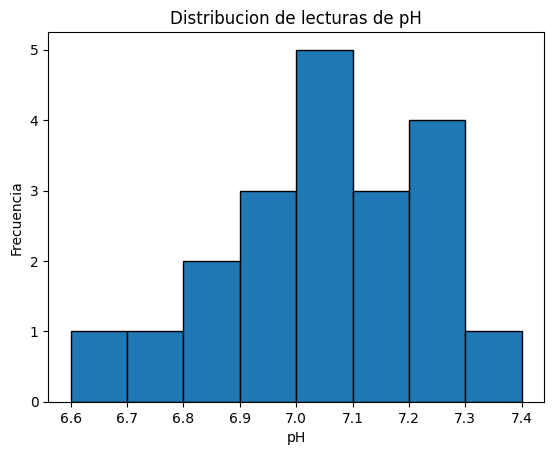

In [9]:
df['ph'].plot.hist(bins=8, title='Distribucion de lecturas de pH',
                   xlabel='pH', ylabel='Frecuencia', edgecolor='black')
plt.show()

*(Al ejecutar se abre la figura: barras que forman una distribución centrada cerca de pH 7.0, con pocas lecturas en los extremos. El histograma muestra dónde se concentran las mediciones.)*

## Tu turno (programa completo)

### Ejercicio: la curva de titulación (química)

En una titulación se mide el `ph` mientras se agrega base (`volumen`, en mL). En `titulacion.csv` están los datos. Léelo y haz una **gráfica de línea** de `ph` contra `volumen`, con **título** y **rótulos de eje con unidades**. Completa la parte que falta.

In [10]:
# TODO: quita los # y completa la parte que falta (el rotulo del eje y, ____).
# titulacion = """volumen,ph
# 0,2.5
# 5,2.8
# 10,3.2
# 15,4.0
# 20,7.0
# 25,10.0
# 30,10.8
# 35,11.2
# """
# with open('titulacion.csv', 'w') as f:
#     f.write(titulacion)
#
# df = pd.read_csv('titulacion.csv')
# df.plot(x='volumen', y='ph', title='Curva de titulacion',
#         xlabel='Volumen de base (mL)', ylabel=____, marker='o', legend=False)
# plt.show()

<details><summary>Respuesta esperada</summary>

La parte que falta es el rótulo del eje y: `ylabel='pH'`. La llamada completa es:

~~~python
df.plot(x='volumen', y='ph', title='Curva de titulacion',
        xlabel='Volumen de base (mL)', ylabel='pH', marker='o', legend=False)
plt.show()
~~~

Al ejecutar se abre la figura: una curva con forma de **S** -- el pH sube poco al principio, da un salto brusco cerca de los 20 mL (el punto de equivalencia) y luego se estabiliza alto. El título y los rótulos con unidades (`Volumen de base (mL)`, `pH`) dejan claro qué se midió. Pusimos `legend=False` porque hay una sola línea.
</details>

## Resumen

- Se grafica con `df.plot` (Pandas se apoya en **matplotlib**, que se importa como `plt`); `plt.show()` muestra la figura.
- **Línea** `df.plot(x=, y=[...])`: algo que cambia a lo largo de una variable (tiempo); varias columnas dan varias líneas con **leyenda**.
- **Barra** `serie.plot.bar()`: comparar un valor entre categorías -- ideal para un `groupby`/`value_counts` de la L22.
- **Dispersión** `df.plot.scatter(x=, y=)`: la relación entre dos variables numéricas.
- **Histograma** `df['col'].plot.hist(bins=n)`: la distribución (la forma) de una columna.
- **Regla de oro:** toda gráfica científica lleva **título**, **rótulos de eje con unidades** y **leyenda** (si hay varias series). Sin eso, la gráfica no comunica.
- **Sigue en la L24:** las imágenes como arreglos de NumPy (otra forma de ver y procesar datos).